In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("student_dataset_100k.csv")

In [6]:
df.head()

,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignments,Internal_Marks,Final_Result
0,1,6,55,57,76,56,Fail
1,2,9,55,58,97,76,Fail
2,3,3,55,69,44,89,Fail
3,4,6,60,63,88,54,Pass
4,5,7,71,55,54,80,Pass


In [7]:
df.isnull().sum()

Student_ID        0
Study_Hours       0
Attendance        0
Previous_Marks    0
Assignments       0
Internal_Marks    0
Final_Result      0
dtype: int64

In [8]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [9]:
df.isnull().sum()

Student_ID        0
Study_Hours       0
Attendance        0
Previous_Marks    0
Assignments       0
Internal_Marks    0
Final_Result      0
dtype: int64

In [10]:
import matplotlib.pyplot as plt

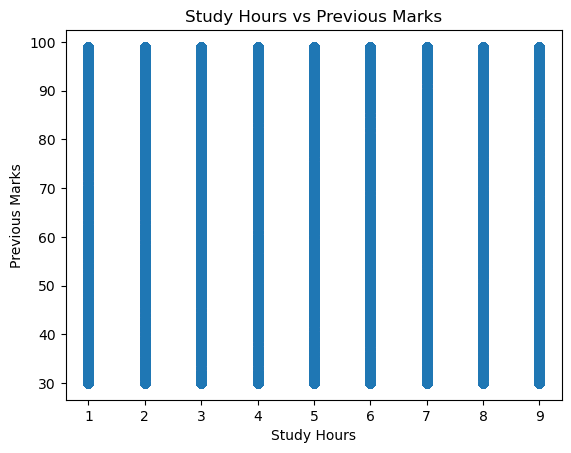

In [11]:
plt.scatter(df['Study_Hours'], df['Previous_Marks'])
plt.xlabel("Study Hours")
plt.ylabel("Previous Marks")
plt.title("Study Hours vs Previous Marks")
plt.show()

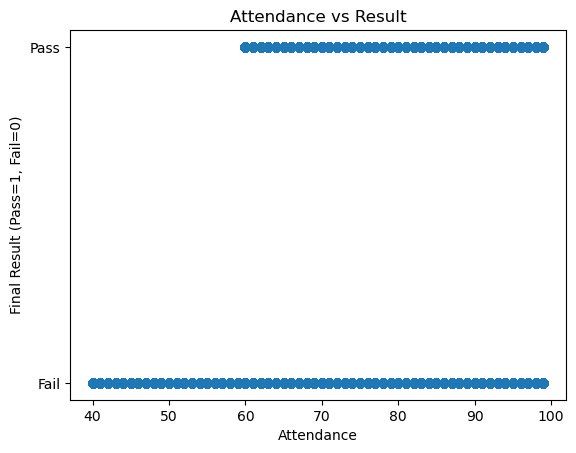

In [12]:
plt.scatter(df['Attendance'], df['Final_Result'])
plt.xlabel("Attendance")
plt.ylabel("Final Result (Pass=1, Fail=0)")
plt.title("Attendance vs Result")
plt.show()

In [13]:
df['Final_Result'] = df['Final_Result'].map({'Pass': 1, 'Fail': 0})

In [14]:
df['Final_Result'] = df['Final_Result'].map({'Pass': 1, 'Fail': 0})

In [15]:
X = df[['Study_Hours', 'Attendance', 'Previous_Marks']]
y = df['Final_Result']

In [16]:
print(X.head())
print(y.head())

   Study_Hours  Attendance  Previous_Marks
0            6          55              57
1            9          55              58
2            3          55              69
3            6          60              63
4            7          71              55
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Final_Result, dtype: float64


In [22]:
# 1. Reload dataset fresh
df = pd.read_csv("student_dataset_100k.csv")

# 2. Convert target
df['Final_Result'] = df['Final_Result'].map({'Pass': 1, 'Fail': 0})

# 3. Remove unwanted column
df = df.drop(['Student_ID'], axis=1)

# 4. Remove ALL missing values (strong fix)
df = df.dropna()

# 5. Select features
X = df[['Study_Hours', 'Attendance', 'Previous_Marks']]
y = df['Final_Result']

# 6. Check again (VERY IMPORTANT)
print(X.isnull().sum())
print(y.isnull().sum())

Study_Hours       0
Attendance        0
Previous_Marks    0
dtype: int64
0


In [23]:
df = df.dropna()

In [27]:
X = df[['Study_Hours', 'Attendance', 'Previous_Marks']]
y = df['Final_Result']

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# -------------------------------
# ✅ USE ONLY NON-LEAKING FEATURES
# -------------------------------
X = df[['Study_Hours', 'Attendance', 'Previous_Marks']]
y = df['Final_Result']

# -------------------------------
# Split data
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Logistic Regression
# -------------------------------
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# -------------------------------
# Decision Tree (controlled)
# -------------------------------
dt = DecisionTreeClassifier(
    max_depth=5,              # control overfitting
    min_samples_split=20,
    random_state=42
)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# -------------------------------
# Naive Bayes
# -------------------------------
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

# -------------------------------
# Accuracy comparison
# -------------------------------
lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)
nb_acc = accuracy_score(y_test, nb_pred)

print("Logistic Regression:", lr_acc)
print("Decision Tree:", dt_acc)
print("Naive Bayes:", nb_acc)

Logistic Regression: 0.722
Decision Tree: 0.80765
Naive Bayes: 0.7374


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [32]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [44]:
import pandas as pd

# Example input
new_data = pd.DataFrame([[6, 85, 78]], 
                        columns=['Study_Hours', 'Attendance', 'Previous_Marks'])

In [45]:
prediction = model.predict(new_data)

In [46]:
if prediction[0] == 1:
    result = "Pass"
else:
    result = "Fail"

print("Prediction:", result)

Prediction: Pass


In [47]:
marks = new_data['Previous_Marks'][0]

if marks >= 85:
    grade = "A"
elif marks >= 70:
    grade = "B"
else:
    grade = "C"

print("Grade:", grade)

Grade: B


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predict using test data
y_pred = model.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.722
Precision: 0.7105178857447945
Recall: 0.7001999368620435
F1 Score: 0.7053211787152851
Confusion Matrix:
 [[7786 2711]
 [2849 6654]]


In [49]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))